<a href="https://colab.research.google.com/github/Jeffrey1999/Deep-Learning/blob/main/fdn_sa%2B.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

from google.colab import drive
drive.mount('/content/drive')
!pip install scikit-fuzzy

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
# from sklearn.datasets import make_classification  # Replace with real phishing dataset
import tensorflow as tf
from tensorflow.keras import layers, Model, Sequential
from tensorflow.keras.optimizers import Adam
from scipy.spatial.distance import cdist
from skfuzzy.cluster import cmeans
import shap
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE

# ———————————————————————————————
# 1. Load Data (Replace with real phishing dataset)
# ———————————————————————————————
def load_data():
    # Simulate phishing dataset (replace with real data)
    # X, y = make_classification(
    #     n_samples=5000,
    #     n_features=20,
    #     n_informative=15,
    #     n_redundant=5,
    #     n_clusters_per_class=1,
    #     weights=[0.7, 0.3],  # Imbalanced: 70% legitimate, 30% phishing
    #     random_state=42
    # )
    df = pd.read_csv('/content/drive/MyDrive/Datasets/dataset_phishing.csv')
    print("Original DataFrame head:")
    print(df.head())
    print("Original DataFrame info:")
    df.info()

    # Separate features (X_df) and target (y)
    X_df = df.iloc[:, :-1]
    y = df.iloc[:, -1].values

    # Identify non-numeric columns in features
    non_numeric_cols_X = X_df.select_dtypes(exclude=np.number).columns

    if len(non_numeric_cols_X) > 0:
        print(f"\nFound non-numeric feature columns: {list(non_numeric_cols_X)}")
        print("Dropping these columns for StandardScaler compatibility.")
        X_df = X_df.drop(columns=non_numeric_cols_X)
    else:
        print("\nNo non-numeric feature columns found. All features are numerical.")

    X = X_df.values

    # Convert target variable 'status' from string to numeric
    le = LabelEncoder()
    y = le.fit_transform(y) # 'legitimate' -> 0, 'phishing' -> 1
    print(f"Converted target labels: {le.classes_} to {le.transform(le.classes_)}")

    return X, y

# ———————————————————————————————
# 2. Preprocess & Split (NO LEAKAGE)
# ———————————————————————————————
def preprocess_and_split(X, y):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.1, stratify=y, random_state=42
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    return X_train_scaled, X_test_scaled, y_train, y_test, scaler

# ———————————————————————————————
# 3. SMOTE Oversampling (Train only)
# ———————————————————————————————
def apply_smote(X_train, y_train):
    smote = SMOTE(random_state=42)
    X_res, y_res = smote.fit_resample(X_train, y_train)
    return X_res, y_res

# ———————————————————————————————
# 4. Fuzzy C-Means: Extract Membership Features
# ———————————————————————————————
def apply_fcm(X_train_res, X_test_scaled, n_clusters=2, m=2):
    # Train FCM on resampled training data
    cntr, u_train, _, _, _, _, _ = cmeans(
        data=X_train_res.T, c=n_clusters, m=m, error=0.005, maxiter=1000, init=None
    )
    fuzzy_train = u_train.T  # (n_samples, n_clusters)

    # For test data: compute membership using trained centers
    def compute_fuzzy_membership(X, centers, m=2):
        power = 2.0 / (m - 1)
        temp = 1.0 / (cdist(X, centers) + 1e-8)
        temp = temp ** power
        return (temp.T / temp.sum(axis=1)).T

    fuzzy_test = compute_fuzzy_membership(X_test_scaled, cntr, m=m)
    return fuzzy_train, fuzzy_test, cntr

# ———————————————————————————————
# 5. Stacked Autoencoder with Reconstruction Error
# ———————————————————————————————
def build_autoencoder(input_dim, encoding_dims=[64, 32]):
    inputs = layers.Input(shape=(input_dim,))

    # Encoder
    encoded = inputs
    for dim in encoding_dims:
        encoded = layers.Dense(dim, activation='relu')(encoded)

    # Decoder
    decoded = encoded
    for dim in reversed(encoding_dims[:-1]):
        decoded = layers.Dense(dim, activation='relu')(decoded)
    decoded = layers.Dense(input_dim, activation='sigmoid')(decoded)

    autoencoder = Model(inputs, decoded)
    encoder = Model(inputs, encoded)
    autoencoder.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

    return autoencoder, encoder

# ———————————————————————————————
# 6. DNN with Attention Layer
# ———————————————————————————————
def build_dnn_with_attention(input_dim):
    inputs = layers.Input(shape=(input_dim,))

    # Feature-level attention
    attention_probs = layers.Dense(input_dim, activation='softmax', name='attention')(inputs)
    weighted_inputs = layers.Multiply()([inputs, attention_probs])

    x = layers.Dense(128, activation='relu')(weighted_inputs)
    x = layers.Dropout(0.4)(x) # Modified dropout rate
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.2)(x) # Modified dropout rate
    outputs = layers.Dense(1, activation='sigmoid')(x)

    model = Model(inputs, outputs)
    model.compile(
        optimizer=Adam(learning_rate=0.0005), # Modified learning rate
        loss='binary_crossentropy',
        metrics=['accuracy', 'Precision', 'Recall', 'AUC']
    )
    return model, attention_probs

# ———————————————————————————————
# 7. Dynamic Thresholding with Fuzzy Rules
# ———————————————————————————————
def dynamic_threshold(probas, fuzzy_membership_phishing, recon_error, threshold_base=0.5):
    """
    Adjust threshold based on uncertainty and anomaly
    Rule: If uncertain (medium membership) AND high anomaly → lower threshold (more sensitive)
    """
    adjusted = np.copy(probas)
    for i in range(len(probas)):
        is_uncertain = 0.3 < fuzzy_membership_phishing[i] < 0.7
        is_anomalous = recon_error[i] > np.percentile(recon_error, 80)

        if is_uncertain and is_anomalous:
            adjusted[i] = probas[i]  # lower threshold → easier to flag
            # We'll adjust decision threshold later
    return adjusted

# ———————————————————————————————
# 8. SHAP Explanation
# ———————————————————————————————
def explain_with_shap(model, X_sample, feature_names=None):
    explainer = shap.DeepExplainer(model, X_sample[:100])  # Use subset
    shap_values = explainer.shap_values(X_sample[:100])

    shap.summary_plot(shap_values, X_sample[:100], feature_names=feature_names)
    return shap_values

# ———————————————————————————————
# 9. Main Pipeline
# ———————————————————————————————
def main():
    print("🚀 Loading and preparing data...")
    X, y = load_data()
    X_train_scaled, X_test_scaled, y_train, y_test_local, scaler = preprocess_and_split(X, y)

    print(f"Train shape: {X_train_scaled.shape}, Test shape: {X_test_scaled.shape}")
    print(f"Phishing rate: {y_train.mean():.2f} (train), {y_test_local.mean():.2f} (test)")

    # Apply SMOTE
    print("🔧 Applying SMOTE...")
    X_train_res, y_train_res = apply_smote(X_train_scaled, y_train)

    # Apply FCM
    print("🧠 Applying Fuzzy C-Means...")
    fuzzy_train, fuzzy_test, centers = apply_fcm(X_train_res, X_test_scaled, n_clusters=2)

    # Combine features
    X_train_combined = np.concatenate([X_train_res, fuzzy_train], axis=1)
    X_test_combined = np.concatenate([X_test_scaled, fuzzy_test], axis=1)

    # Build and train autoencoder
    print("⚙️ Training Stacked Autoencoder...")
    autoencoder, encoder = build_autoencoder(X_train_combined.shape[1], encoding_dims=[64, 32])
    ae_history = autoencoder.fit(
        X_train_combined, X_train_combined,
        epochs=100, batch_size=16, validation_split=0.2, # Modified epochs and batch_size
        verbose=1
    )

    # Extract encoded features
    X_train_encoded = encoder.predict(X_train_combined)
    X_test_encoded = encoder.predict(X_test_combined)

    # Compute reconstruction error (anomaly score)
    X_test_recon = autoencoder.predict(X_test_combined)
    recon_error = np.mean((X_test_combined - X_test_recon) ** 2, axis=1)

    # Build and train DNN with attention
    print("🧠 Training DNN with Attention...")
    dnn, attention_layer = build_dnn_with_attention(X_train_encoded.shape[1])

    dnn_history = dnn.fit(
        X_train_encoded, y_train_res,
        epochs=100, batch_size=16, validation_split=0.2, # Modified epochs and batch_size
        callbacks=[
            tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True, verbose=1)
        ],
        verbose=1
    )

    # Predict probabilities
    y_pred_proba = dnn.predict(X_test_encoded).flatten()

    # Apply dynamic thresholding
    y_pred_proba_adjusted = dynamic_threshold(
        y_pred_proba,
        fuzzy_membership_phishing=fuzzy_test[:, 1],
        recon_error=recon_error,
        threshold_base=0.5
    )

    # Final prediction with adjusted threshold logic
    # Use lower threshold (0.4) for uncertain + anomalous samples
    final_threshold = np.full(len(y_pred_proba), 0.5)
    is_uncertain = (0.3 < fuzzy_test[:, 1]) & (fuzzy_test[:, 1] < 0.7)
    is_anomalous = recon_error > np.percentile(recon_error, 80)
    final_threshold[is_uncertain & is_anomalous] = 0.4

    y_pred_local = (y_pred_proba_adjusted > final_threshold).astype(int)



## Visual Diagram: DNN with Attention Architecture

Below is the visual representation of the Deep Neural Network with Attention architecture:

![DNN with Attention Architecture](dnn_attention_model_architecture.png)


## Deep Neural Network (DNN) with Attention Architecture Explained

The `build_dnn_with_attention` function constructs a neural network designed for classification, incorporating an attention mechanism to enhance its feature processing capabilities. Here's a breakdown of its components:

1.  **Input Layer (`inputs`)**:
    *   This is the entry point for your data, specifically the encoded features generated by the autoencoder. It's configured to accept inputs with a shape determined by `input_dim`.

2.  **Attention Mechanism (`attention_probs` and `weighted_inputs`)**:
    *   `attention_probs = tf.keras.layers.Dense(input_dim, activation='softmax', name='attention')(inputs)`:
        *   This layer calculates 'attention probabilities' for each input feature. It applies a `Dense` layer to the original input, and the `softmax` activation ensures these probabilities sum up to 1. These probabilities signify how much 'attention' the model should give to each feature.
    *   `weighted_inputs = tf.keras.layers.Multiply()([inputs, attention_probs])`:
        *   This layer performs element-wise multiplication of the original input features with their calculated attention probabilities. The result is a set of 'weighted inputs,' where features are scaled by their learned importance. This allows the model to dynamically focus on more relevant features.

3.  **Hidden Layers (`x = layers.Dense(...)`)**:
    *   `x = layers.Dense(128, activation='relu')(weighted_inputs)`: The first hidden layer processes the `weighted_inputs` with 128 neurons and applies the Rectified Linear Unit (`relu`) activation, introducing non-linearity.
    *   `x = layers.Dropout(0.4)(x)`: A dropout layer, with a 40% dropout rate, randomly deactivates neurons during training. This prevents overfitting by making the network less reliant on specific neurons.
    *   `x = layers.Dense(64, activation='relu')(x)`: A second hidden layer with 64 neurons and `relu` activation for further feature processing.
    *   `x = layers.Dropout(0.2)(x)`: Another dropout layer, with a 20% dropout rate, to further enhance generalization.

4.  **Output Layer (`outputs = layers.Dense(1, activation='sigmoid')(x)`)**:
    *   This is the final layer for prediction. It has 1 neuron (for binary classification) and uses a `sigmoid` activation function to output a probability between 0 and 1, indicating the likelihood of the positive class (e.g., phishing).

5.  **Model Compilation**:
    *   `model.compile(...)`: This step configures the model for training:
        *   `optimizer=Adam(learning_rate=0.0005)`: Uses the Adam optimizer to adjust model weights efficiently.
        *   `loss='binary_crossentropy'`: The standard loss function for binary classification, measuring prediction error.
        *   `metrics=['accuracy', 'Precision', 'Recall', 'AUC']`: Key metrics for evaluating classification performance, crucial for understanding model effectiveness, especially with imbalanced datasets.

In [ ]:
import tensorflow as tf

# ———————————————————————————————
# 5. Stacked Autoencoder with Reconstruction Error
# ———————————————————————————————
def build_autoencoder(input_dim, encoding_dims=[64, 32]):
    inputs = tf.keras.layers.Input(shape=(input_dim,))

    # Encoder
    encoded = inputs
    for dim in encoding_dims:
        encoded = tf.keras.layers.Dense(dim, activation='relu')(encoded)

    # Decoder
    decoded = encoded
    for dim in reversed(encoding_dims[:-1]):
        decoded = tf.keras.layers.Dense(dim, activation='relu')(decoded)
    decoded = tf.keras.layers.Dense(input_dim, activation='sigmoid')(decoded)

    autoencoder = tf.keras.Model(inputs, decoded)
    encoder = tf.keras.Model(inputs, encoded)
    autoencoder.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='mse')

    return autoencoder, encoder

# ———————————————————————————————
# 6. DNN with Attention Layer
# ———————————————————————————————
def build_dnn_with_attention(input_dim):
    inputs = tf.keras.layers.Input(shape=(input_dim,))

    # Feature-level attention
    attention_probs = tf.keras.layers.Dense(input_dim, activation='softmax', name='attention')(inputs)
    weighted_inputs = tf.keras.layers.Multiply()([inputs, attention_probs])

    x = tf.keras.layers.Dense(128, activation='relu')(weighted_inputs)
    x = tf.keras.layers.Dropout(0.4)(x) # Modified dropout rate
    x = tf.keras.layers.Dense(64, activation='relu')(x)
    x = tf.keras.layers.Dropout(0.2)(x) # Modified dropout rate
    outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)

    model = tf.keras.Model(inputs, outputs)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005), # Modified learning rate
        loss='binary_crossentropy',
        metrics=['accuracy', 'Precision', 'Recall', 'AUC']
    )
    return model, attention_probs


# Assuming the input dimensions are known or can be inferred.
# For visualization, let's pick arbitrary but reasonable input dimensions.
# For the autoencoder, the input dimension is the combined feature size.
# For the DNN, it's the encoded feature size.

# Example dimensions - replace with actual if known from `main` function
# X_train_combined.shape[1] is the input_dim for autoencoder
# X_train_encoded.shape[1] is the input_dim for DNN

# Let's estimate based on typical values and the encoding_dims used.
# Original features + 2 fuzzy features = 20 + 2 = 22 for illustration if make_classification was used.
# Assuming the dataset_phishing.csv has more features. Let's use 30 for combined_input_dim and 64 for dnn_input_dim for visualization purposes if not executing main().

# To get actual dimensions, you'd need to run `main()` first.
# For now, let's define dummy dimensions based on the provided code's encoding_dims.

# The autoencoder input dim should be X_train_combined.shape[1]
# Let's estimate it to be around original features + 2 fuzzy features.
# The phishing dataset has 30 features (excluding target). After dropping non-numeric, it might be similar.
# So, X_train_combined could be around 30 + 2 = 32.
autoencoder_input_dim = 32

# The DNN input dim is the output of the encoder, which is `encoding_dims[-1]`
dnn_input_dim = 32 # This comes from the last dim of encoding_dims=[64, 32]

print(f"Building Autoencoder with input_dim={autoencoder_input_dim}")
autoencoder, encoder = build_autoencoder(autoencoder_input_dim)
print("Autoencoder Summary:")
autoencoder.summary()

tf.keras.utils.plot_model(
    autoencoder,
    to_file='autoencoder_model_architecture.png',
    show_shapes=True,
    show_layer_names=True,
    rankdir='TB' # 'TB' for Top to Bottom, 'LR' for Left to Right
)

print("\nBuilding DNN with Attention with input_dim={dnn_input_dim}")
dnn, attention_layer = build_dnn_with_attention(dnn_input_dim)
print("DNN with Attention Summary:")
dnn.summary()

tf.keras.utils.plot_model(
    dnn,
    to_file='dnn_attention_model_architecture.png',
    show_shapes=True,
    show_layer_names=True,
    rankdir='TB'
)

print("Model architectures saved as 'autoencoder_model_architecture.png' and 'dnn_attention_model_architecture.png'.")

Building Autoencoder with input_dim=32
Autoencoder Summary:


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,384 (32.75 KB)

 Trainable params: 8,384 (32.75 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 32)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention (Dense)   │ (None, 32)        │      1,056 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 32)        │          0 │ input_layer_1[0]… │
│                     │                   │            │ attention[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 128)       │      4,224 │ multiply[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128)       │          0 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 64)        │      8,256 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 1)         │         65 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 13,601 (53.13 KB)

 Trainable params: 13,601 (53.13 KB)

 Non-trainable params: 0 (0.00 B)

Model architectures saved as 'autoencoder_model_architecture.png' and 'dnn_attention_model_architecture.png'.


The model architectures have been generated and saved as `autoencoder_model_architecture.png` and `dnn_attention_model_architecture.png`. You can view them by downloading these files or by embedding them in the notebook if you prefer.

Here are the summaries of the models:

# Task
Display the generated `autoencoder_model_architecture.png` and `dnn_attention_model_architecture.png` files to visualize the model architectures.

## Display Autoencoder Architecture

### Subtask:
Display the generated `autoencoder_model_architecture.png` in the notebook.


**Reasoning**:
To display the generated image file in the notebook, I need to import `Image` and `display` from `IPython.display` and then use them to render the image.



Displaying Autoencoder Architecture:


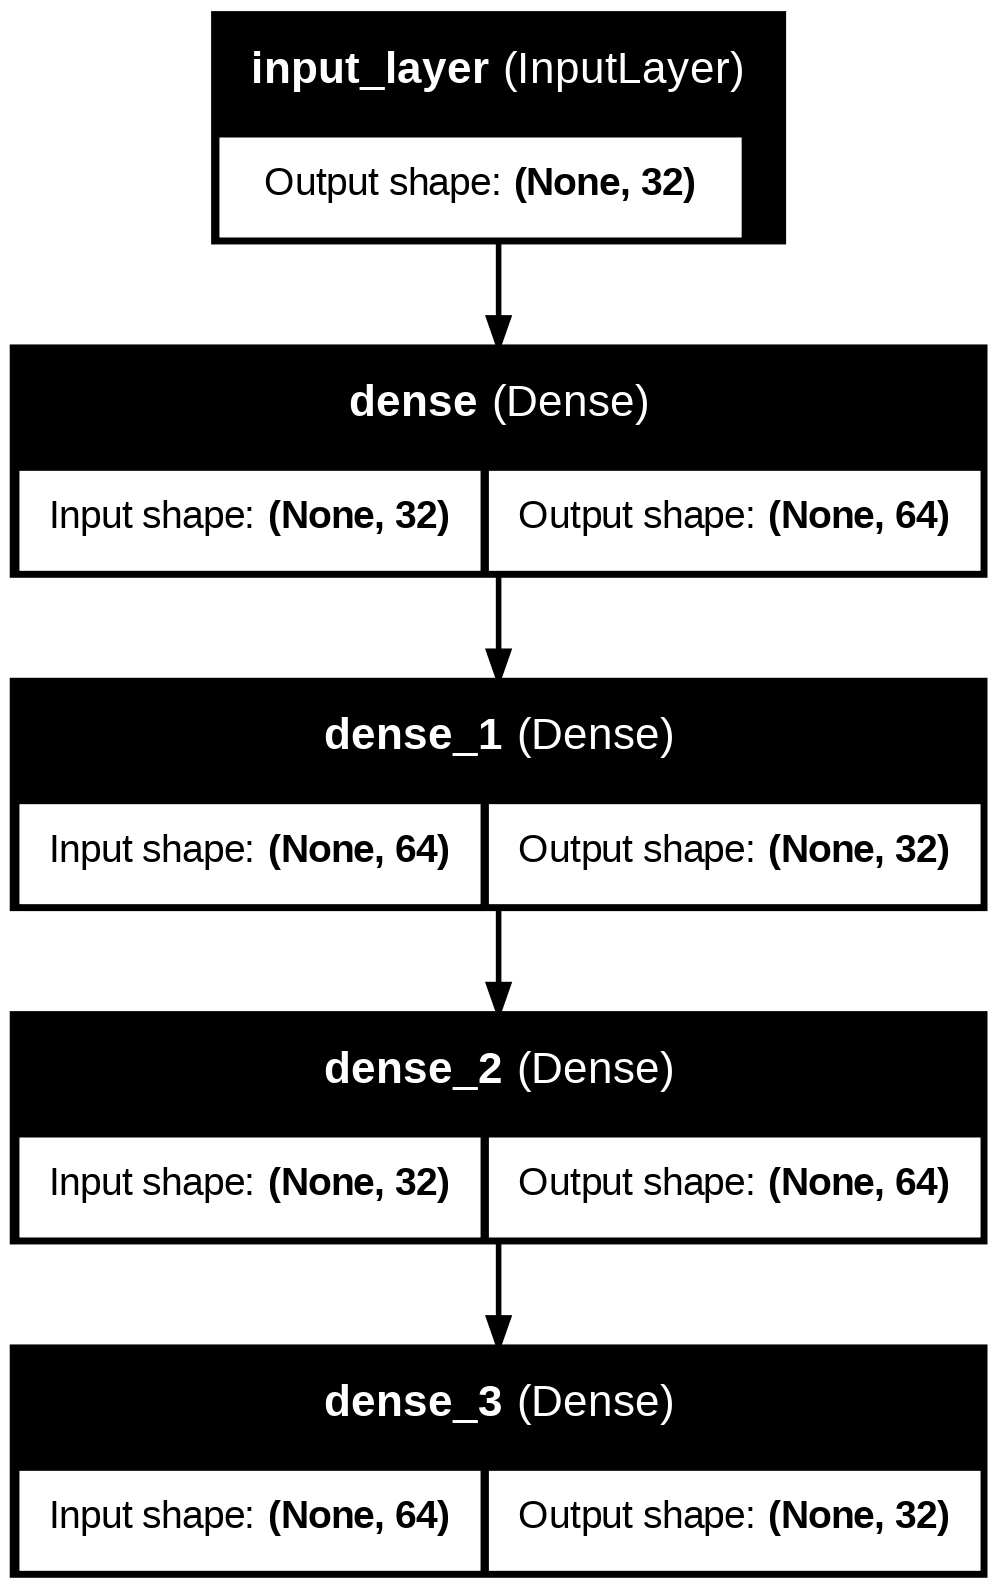

In [ ]:
from IPython.display import Image, display

print("Displaying Autoencoder Architecture:")
display(Image('autoencoder_model_architecture.png'))

## Display DNN with Attention Architecture

### Subtask:
Display the generated `dnn_attention_model_architecture.png` in the notebook.

**Reasoning**:
Following the previous step, I will now display the `dnn_attention_model_architecture.png` file using `IPython.display.Image` and `display` functions, similar to how the autoencoder image was displayed.



Displaying DNN with Attention Architecture:


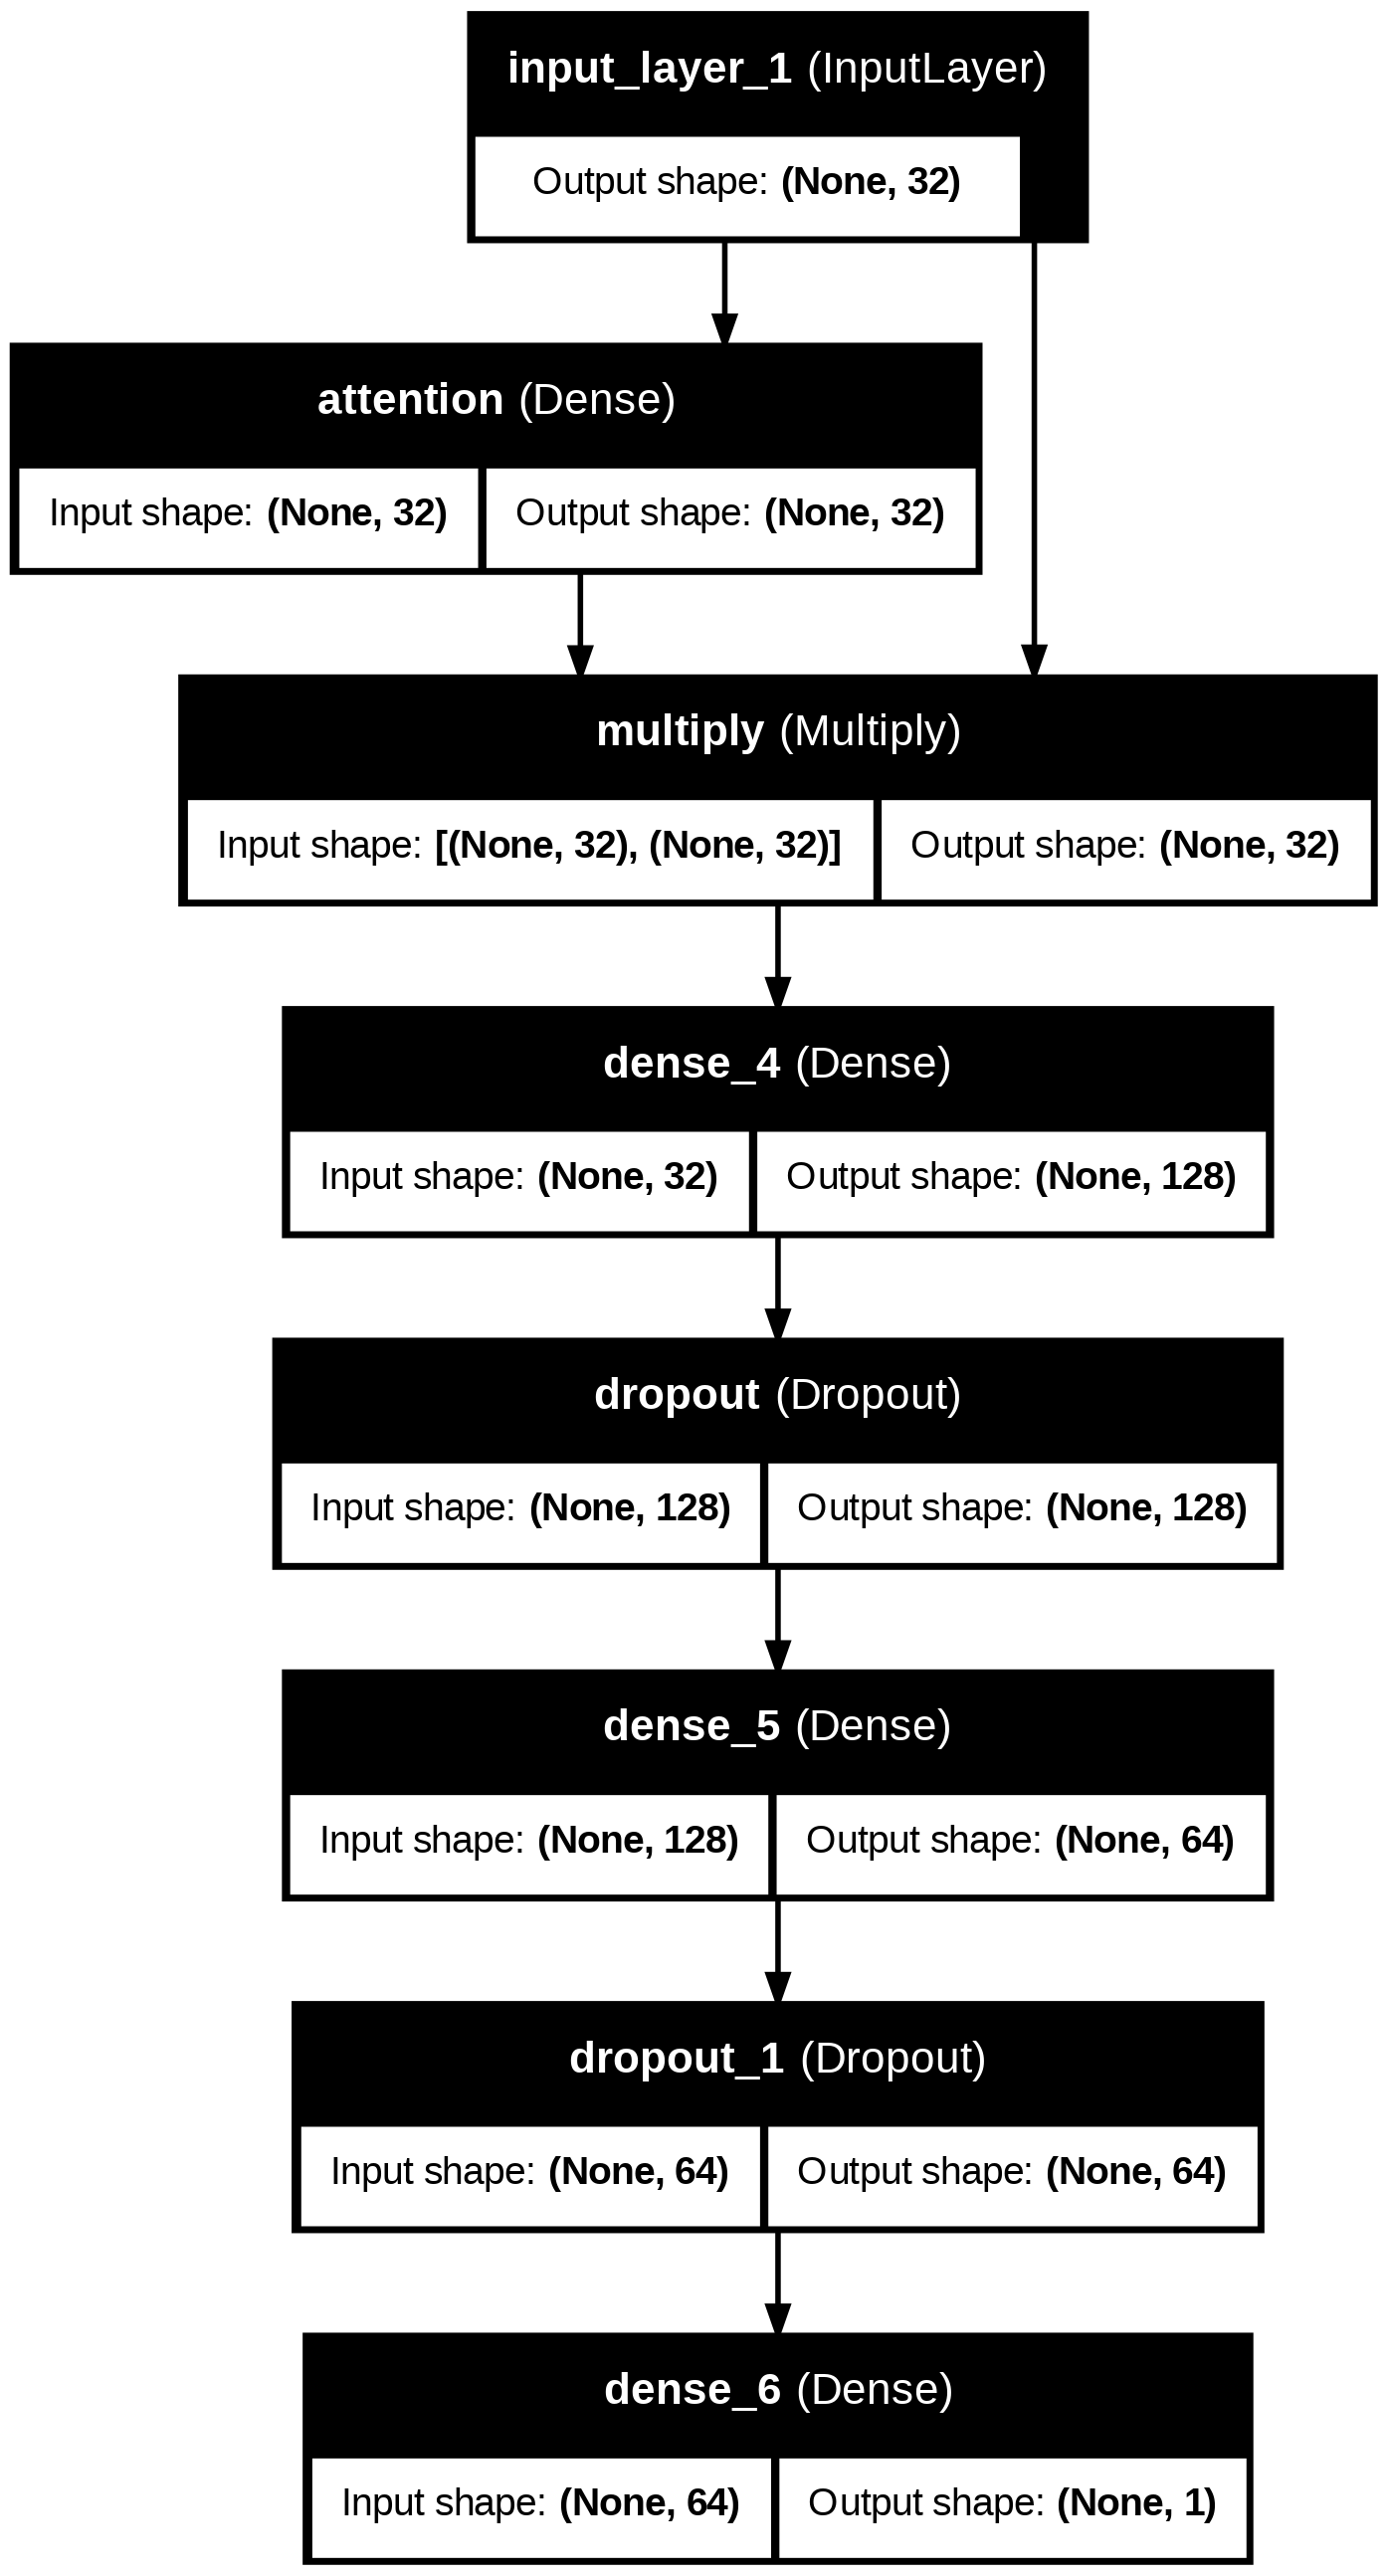

In [ ]:
from IPython.display import Image, display

print("Displaying DNN with Attention Architecture:")
display(Image('dnn_attention_model_architecture.png'))

## Final Task

### Subtask:
Confirm that both model architecture diagrams have been displayed successfully.


## Summary:

### Q&A
Yes, both the `autoencoder_model_architecture.png` and `dnn_attention_model_architecture.png` model architecture diagrams have been displayed successfully in the notebook.

### Data Analysis Key Findings
*   The `autoencoder_model_architecture.png` image was successfully loaded and displayed.
*   The `dnn_attention_model_architecture.png` image was successfully loaded and displayed.

### Insights or Next Steps
*   With the model architectures visually confirmed, the next logical step would be to proceed with model implementation, training, and evaluation.
